# 3.2 ***从零开始的线性回归***

In [ ]:
import random
import torch
from d2l import torch as d2l

### 3.2.1 *数据集——y=Xw+b*

In [ ]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

### 3.2.2 *读取数据集*

In [ ]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

### 3.2.3 *参数初始化*

In [ ]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

### 3.2.4 *定义模型——线性回归模型*

In [ ]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

### 3.2.5 *损失函数——MSE*

In [ ]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

### 3.2.6 *优化函数——小批量随机梯度下降*

In [ ]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 3.2.7 *训练过程*

In [ ]:
lr, num_epochs, net, loss = 0.03, 3, linreg, squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(10, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, 10)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

In [ ]:
# 比较真实参数和训练得到的参数
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

# 3.3 ***简洁的实现线性回归***

数据迭代器、损失函数、优化器和神经网络层已在深度学习库中实现

In [ ]:
import torch
from torch.utils import data
from d2l import torch as d2l

### 3.3.1 *数据集*

In [ ]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

### 3.3.2 *读取数据集——torch库的data模组的DataLoader方法*

In [ ]:
batch_size = 10
data_iter = d2l.load_array((features, labels), batch_size)
# 使用next(iter(data_iter))可以从data_iter中获取一个小批量数据
next(iter(data_iter))
# for X, y in data_iter:
#     print(X, '\n', y)
#     break

### 3.3.3 *定义模型*

In [ ]:
# Sequential类将各个层串联在一起，将上一层的输出作为下一层的输入
net = torch.nn.Sequential(
    torch.nn.Linear(2, 1)
)

### 3.3.4 *初始化参数*

In [ ]:
# 可以通过net[i]来访问神经网络第i层
# 再使用weight.data和bias.data来访问第i层的权重和偏差的参数
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

### 3.3.5 *损失函数——MSE*

In [ ]:
loss = torch.nn.MSELoss()

### 3.3.6 *优化算法——梯度下降*

In [ ]:
train = torch.optim.SGD(net.parameters(), lr=0.03)

### 3.3.7 *训练过程*

In [ ]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        train.zero_grad()
        l.backward()
        train.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

In [ ]:
w, b = net[0].weight.data, net[0].bias.data
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

# 3.4 ***从零开始的softmax回归——分类问题***

使用FASHION-MNIST数据集

In [ ]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l
from IPython import display

d2l.use_svg_display()

In [ ]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

### 3.4.1 *初始化参数*

In [ ]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

### 3.4.2 *定义模型*

In [ ]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition

### 3.4.3 *损失函数——交叉熵*

In [ ]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])

### 3.4.4 *优化算法——梯度下降*

In [ ]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

### 3.4.5 *训练过程*

In [ ]:
num_epochs = 10
d2l.train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

### 3.4.6 *预测*

In [ ]:
d2l.predict_ch3(net, test_iter)

# 3.5 ***简洁的实现softmax回归***

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

### 3.5.1 *初始化参数*

In [2]:
net = nn.Sequential(nn.Flatten(),nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)

net.apply(init_weights);

# 3.5.2 损失函数

In [3]:
loss = nn.CrossEntropyLoss(reduction='none')

# 3.5.3 优化算法

In [4]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

# 3.5.4 训练过程

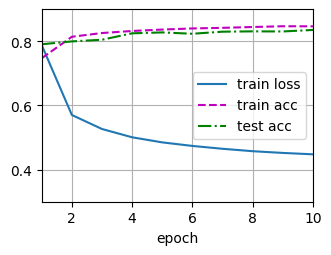

In [5]:
num_epochs = 10
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

In [ ]:
d2l.predict_ch3(net, test_iter)